In [4]:
# pip install mediapipe
# pip install pytesserect

In [3]:
pip freeze

absl-py==2.1.0
aiobotocore @ file:///C:/b/abs_1c1a_vjay2/croot/aiobotocore_1682537737724/work
aiofiles @ file:///C:/b/abs_9ex6mi6b56/croot/aiofiles_1683773603390/work
aiohttp @ file:///C:/b/abs_b78zt6vo64/croot/aiohttp_1694181126607/work
aioitertools @ file:///tmp/build/80754af9/aioitertools_1607109665762/work
aiosignal @ file:///tmp/build/80754af9/aiosignal_1637843061372/work
aiosqlite @ file:///C:/b/abs_9djc_0pyi3/croot/aiosqlite_1683773915844/work
alabaster @ file:///home/ktietz/src/ci/alabaster_1611921544520/work
anaconda-anon-usage @ file:///C:/b/abs_f4tsjyl9va/croot/anaconda-anon-usage_1695310457827/work
anaconda-catalogs @ file:///C:/b/abs_8btyy0o8s8/croot/anaconda-catalogs_1685727315626/work
anaconda-client @ file:///C:/b/abs_80wttmgui4/croot/anaconda-client_1694625288614/work
anaconda-cloud-auth @ file:///C:/b/abs_5cjpnu6wjb/croot/anaconda-cloud-auth_1694462130037/work
anaconda-navigator @ file:///C:/b/abs_cfvv8k_j21/croot/anaconda-navigator_1704813334508/work
anaconda-project

In [1]:
import mediapipe as mp
import cv2
import time
import numpy as np
import os
from time import sleep
from pynput.keyboard import Controller
import numpy as np

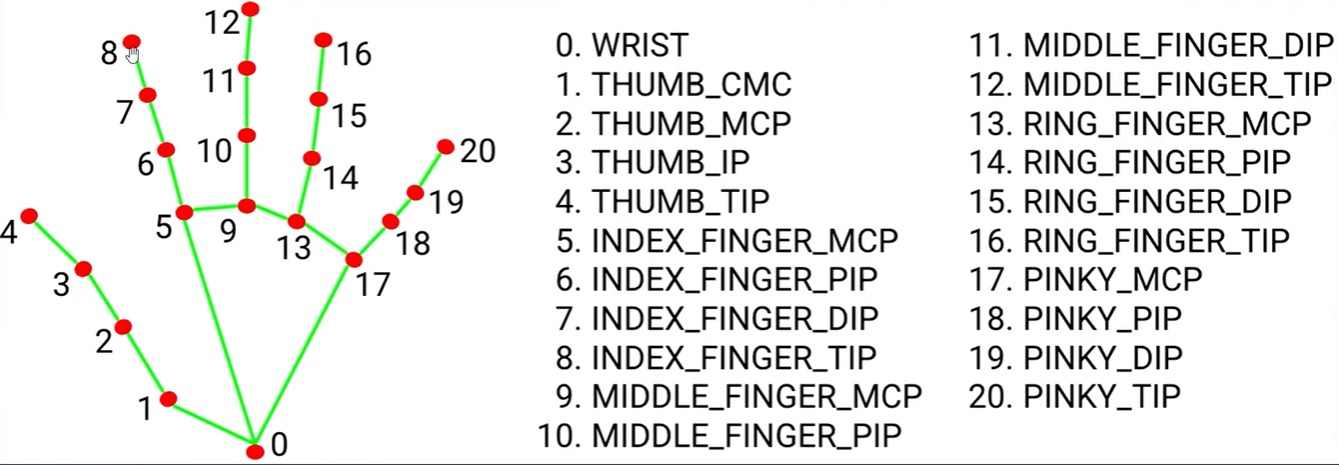

In [3]:
camera = cv2.VideoCapture(0)
resolucao_x = 1280
resolucao_y = 720
camera.set(cv2.CAP_PROP_FRAME_WIDTH, resolucao_x)
camera.set(cv2.CAP_PROP_FRAME_HEIGHT, resolucao_y)
notepad = False
calculator = False
edge = False
keys = [
    ['Q', 'W', 'E', 'R', 'T', 'Y', 'U', 'I', 'O', 'P'],
    ['A', 'S', 'D', 'F', 'G', 'H', 'J', 'K', 'L'],
    ['Z', 'X', 'C', 'V', 'B', 'N', 'M', ',', '.', ' ']
    ]
offset = 50
count = 0
text = '> '
keyboard = Controller()
img_quadro = np.ones((resolucao_y, resolucao_x, 3), np.uint8)*255
cor_pincel = (255,0,0)
espessura_pincel = 7
x_quadro, y_quadro = 0, 0

mp_hands = mp.solutions.hands
mp_desenho = mp.solutions.drawing_utils
hands = mp_hands.Hands()

def find_coord(img, side_inverted = False):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resultado = hands.process(img_rgb)
    all_hands = []
    if resultado.multi_hand_landmarks:
        for side_hand, marcacoes in zip(resultado.multi_handedness, resultado.multi_hand_landmarks):
            coord = []
            info_hand = {}
            for marcacao in marcacoes.landmark:
                coord_x, coord_y, coord_z = int(marcacao.x *resolucao_x), int(marcacao.y * resolucao_y), int(marcacao.z * resolucao_x)
                coord.append((coord_x, coord_y, coord_z))

            info_hand['coord'] = coord
            if side_inverted:
                if side_hand.classification[0].label == 'Left':
                    info_hand['side'] = 'Right'
                else:
                    info_hand['side'] = 'Left'
            else:
                info_hand['side'] = side_hand.classification[0].label
                
            all_hands.append(info_hand)
            mp_desenho.draw_landmarks(img,
                                      marcacoes,
                                      mp_hands.HAND_CONNECTIONS)
    
    return img, all_hands

def fingers_raised(hand):
    fingers = []
    for ponta_dedo in [8, 12, 16, 20]:
        if hand['coord'][ponta_dedo][1] < hand['coord'][ponta_dedo - 2][1]:
            fingers.append(True)
        else:
            fingers.append(False)
    return fingers

def print_buttons(img, position, key, tam = 50, color = (255,255,255)):
    cv2.rectangle(img, position, (position[0]+tam, position[1]+tam), color, cv2.FILLED)
    cv2.rectangle(img, position, (position[0]+tam, position[1]+tam), (255,100,0), 2)
    cv2.putText(img, key, (position[0]+15, position[1]+35), cv2.FONT_HERSHEY_COMPLEX, 1, (0,0,0), 2)
    return img
    

while True:
    sucess, img = camera.read()
    img = cv2.flip(img, 1)# 1: faz com que a imagem seja espelhada horizontalmente;
# 0: faz com que a imagem seja espelhada verticalmente;
# -1: faz com que a imagem seja espelhada horizontalmente e verticalmente simultaneamente.
    img, all_hands = find_coord(img)
    
    
    if len(all_hands) == 1:
        info_fingers_hand1 = fingers_raised(all_hands[0])
        if all_hands[0]['side'] == 'Left':
            indicador_x, indicador_y, indicador_z = all_hands[0]['coord'][8]
            cv2.putText(img, f'Distancia camera: {indicador_z}', (850, 50), cv2.FONT_HERSHEY_COMPLEX, 1, (0,0,0), 2)
            
            for line_idx, line_key in enumerate(keys):
                for idx, letter in enumerate(line_key):
                    if sum(info_fingers_hand1) <= 1:
                        letter = letter.lower()
                        
                    img = print_buttons(img, (offset+idx*80, offset+line_idx*80), letter)
                    if offset+idx*80 < indicador_x < 100+idx*80 and offset+line_idx*80<indicador_y<100+line_idx*80:
                        img = print_buttons(img, (offset+idx*80, offset+line_idx*80), letter, color=(0,255,0))
                        if indicador_z < -85:
                            count = 1
                            escreve = letter
                            img = print_buttons(img, (offset+idx*80, offset+line_idx*80), letter, color=(255,255,0))
                            
            if count:
                count += 1
                if count == 3:
                    text += escreve
                    count = 0
                    keyboard.press(escreve)
                
            if info_fingers_hand1 == [False, False, False, True] and len(text) > 1:
                text = text[:-1]
                sleep(0.15)
                    
            cv2.rectangle(img, (offset, 450), (830,500), (255,255,255), cv2.FILLED)
            cv2.rectangle(img, (offset, 450), (830,500), (0,0,255), 2)
            cv2.putText(img, text[-40:], (offset, 480), cv2.FONT_HERSHEY_COMPLEX, 1, (0,0,0), 2)
            cv2.circle(img, (indicador_x, indicador_y), 7, (0,0,255), cv2.FILLED)
            
        if all_hands[0]['side'] == 'Right':
            if info_fingers_hand1 == [True, False, False, False] and notepad == False:
                os.startfile(r'C:\Windows\System32\notepad.exe')
                notepad = True

            if info_fingers_hand1 == [True, True, False, False] and edge == False:
                os.startfile(r'C:\Program Files (x86)\Microsoft\Edge\Application\msedge.exe')
                edge = True

            if info_fingers_hand1 == [True, True, True, False] and calculator == False:
                os.startfile(r'C:\Windows\System32\calc.exe')
                calculator = True

            if (info_fingers_hand1 == [False, False, False, False]) and (notepad == True | calculator == True | edge == True):
                notepad = False
                calculator = False
                edge = False
                os.system('TASKKILL /IM notepad.exe')
                os.system('TASKKILL /IM msedge.exe')
                os.system('TASKKILL /IM calc.exe')

            if info_fingers_hand1 == [True, False, False, True]:
                break
    
    if len(all_hands) == 2:
        info_fingers_hand1 = fingers_raised(all_hands[0])
        info_fingers_hand2 = fingers_raised(all_hands[1])
    
        indicador_x, indicador_y, indicador_z = all_hands[0]['coord'][8]
        
        if sum(info_fingers_hand2) == 1:
            cor_pincel = (0,0,255)
        elif sum(info_fingers_hand2) == 2:
            cor_pincel = (0,255,0)
        elif sum(info_fingers_hand2) == 3:
            cor_pincel = (255,0,0)
        elif sum(info_fingers_hand2) == 4:
            cor_pincel = (255,255,255)
        else:
            img_quadro = np.ones((resolucao_y, resolucao_x, 3), np.uint8)*255
            
        espessura_pincel = int(abs(indicador_z)) // 3 + 5 #permanece divisao inteira
        cv2.circle(img, (indicador_x, indicador_y), espessura_pincel, cor_pincel, cv2.FILLED)
        
        if info_fingers_hand1 == [True, False, False, False]:
            if x_quadro ==0 and y_quadro ==0:
                x_quadro, y_quadro = indicador_x, indicador_y
            
            cv2.line(img_quadro, (x_quadro, y_quadro), (indicador_x, indicador_y), cor_pincel, espessura_pincel)
            x_quadro, y_quadro = indicador_x, indicador_y
            
        else:
            x_quadro, y_quadro = 0, 0
        
        img = cv2.addWeighted(img, 1, img_quadro, 0.2, 0)
        
        
    cv2.imshow('webcam', img)
    cv2.imshow('quadro', img_quadro)
    
    tecla = cv2.waitKey(1)
    if tecla == 'q':
        break
    if tecla == 27: # 27 = 'Esc'
        break
        
with open('text.txt', 'w') as f:
    f.write(text)
    
cv2.imwrite('quadro.png', img_quadro)

True

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "C:\ProgramData\anaconda3\Lib\asyncio\selector_events.py", line 119, in _read_from_self
    data = self._ssock.recv(4096)
           ^^^^^^^^^^^^^^^^^^^^^^
ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "C:\ProgramData\anaconda3\Lib\asyncio\selector_events.py", line 119, in _read_from_self
    data = self._ssock.recv(4096)
           ^^^^^^^^^^^^^^^^^^^^^^
ConnectionReset

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "C:\ProgramData\anaconda3\Lib\asyncio\selector_events.py", line 119, in _read_from_self
    data = self._ssock.recv(4096)
           ^^^^^^^^^^^^^^^^^^^^^^
ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "C:\ProgramData\anaconda3\Lib\asyncio\selector_events.py", line 119, in _read_from_self
    data = self._ssock.recv(4096)
           ^^^^^^^^^^^^^^^^^^^^^^
ConnectionReset

Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "C:\ProgramData\anaconda3\Lib\asyncio\selector_events.py", line 119, in _read_from_self
    data = self._ssock.recv(4096)
           ^^^^^^^^^^^^^^^^^^^^^^
ConnectionResetError: [WinError 10054] An existing connection was forcibly closed by the remote host
Exception in callback BaseSelectorEventLoop._read_from_self()
handle: <Handle BaseSelectorEventLoop._read_from_self()>
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\asyncio\events.py", line 80, in _run
    self._context.run(self._callback, *self._args)
  File "C:\ProgramData\anaconda3\Lib\asyncio\selector_events.py", line 119, in _read_from_self
    data = self._ssock.recv(4096)
           ^^^^^^^^^^^^^^^^^^^^^^
ConnectionReset

## Pontos importantes

* Utilizar a biblioteca OpenCV para se conectar a webcam do computador;
* Detectar as mãos em vídeos com a biblioteca MediaPipe;
* Representar visualmente pontos de referência das mãos em imagens com a solução drawing_utils;
* Fazer a conversão dos canais de cores (RGB → BGR) com o método cvtColor() para o processamento da imagem com o método process().
* Extrair e armazenar as coordenadas dos pontos de referência das mãos com a biblioteca mediapipe;
* Espelhar imagens utilizando a biblioteca OpenCV;
* Coletar a informação de qual é o lado da mão presente em uma imagem através do multi_handedness.
* Construir uma função para detectar quais dedos da mão estão levantados;
* Elaborar uma solução para abrir programas do computador utilizando a biblioteca os e a função que checa quais dedos estão levantados;
* Elaborar uma solução para encerrar processos do computador utilizando a biblioteca os e a função que checa quais dedos estão levantados.
* Utilizar a biblioteca OpenCV para representar formas geométricas e textos em imagens;
* Construir a parte visual de um teclado virtual utilizando OpenCV;
* Criar a lógica de utilização de um teclado com a linguagem Python;
* Controlar o teclado do computador utilizando a biblioteca pynput.
* Criar uma ferramenta de desenho, utilizando o python e OpenCV, incluindo funções de apagar, alternância de espessura do pincel e armazenamento da imagem;
* Alterar cores de elementos na imagem utilizando gestos de mãos;
* Sobrepor imagens utilizando a biblioteca OpenCV.